## Тык

In [49]:
import skmob
from skmob.utils import utils, constants
from skmob.models.gravity import Gravity

import numpy as np
import pandas as pd
import geopandas as gpd

import osmnx as ox
from shapely.geometry import Polygon

url_tess = skmob.utils.constants.NY_COUNTIES_2011
tessellation = gpd.read_file(url_tess).rename(columns={'tile_id': 'tile_ID'})

fdf = skmob.FlowDataFrame.from_file(skmob.utils.constants.NY_FLOWS_2011,
                                        tessellation=tessellation,
                                        tile_id='tile_ID',
                                        sep=",")

                                     
tot_outflows = fdf[fdf['origin'] != fdf['destination']].groupby(by='destination', axis=0)[['flow']].sum().fillna(0) # Группировка по городам и подсчет миграции в каждый город
tessellation = tessellation.merge(tot_outflows, left_on='tile_ID', right_on='destination').rename(columns={'flow': constants.TOT_OUTFLOW}) # Merge с городами, населением и геометрией

In [50]:
import osmnx as ox
import geopandas as gpd
from tqdm import tqdm

# Загрузка данных (пример)
# tessellation = gpd.read_file('your_data.geojson')

# Определение тегов OSM
tags_config = {
    'clinic': {'amenity': 'clinic'},
    'theatre': {'amenity': 'theatre'},
    'museum': {'tourism': 'museum'},
    'park': {'leisure': 'park'}
}

# Функция для подсчета объектов
def count_pois(polygon, tag):
    try:
        print(f'"{list(tag.keys())[0]}":"{list(tag.values())[0]}"')
        gdf = ox.features_from_polygon(
            polygon,
            tags=tag,
            # custom_filter=f'"{list(tag.keys())[0]}":"{list(tag.values())[0]}"'
        )
        return gdf[gdf.geometry.notnull()].shape[0]
    except:
        return 0

# Добавляем колонки для каждого типа объектов
for category in tags_config:
    tessellation[f'{category}'] = 0

# Обрабатываем все полигоны с визуализацией прогресса
for idx, row in tqdm(tessellation.iterrows(), total=len(tessellation)):
    geom = row.geometry
    for category, tag in tags_config.items():
        count = count_pois(geom, tag)
        tessellation.at[idx, f'{category}'] = count

# Результат
print(tessellation[['tile_ID', 'clinic', 'theatre', 'museum', 'park']].head())

  0%|          | 0/62 [00:00<?, ?it/s]

"amenity":"clinic"
"amenity":"theatre"
"tourism":"museum"
"leisure":"park"


  2%|▏         | 1/62 [00:01<01:07,  1.11s/it]

"amenity":"clinic"
"amenity":"theatre"
"tourism":"museum"
"leisure":"park"


  3%|▎         | 2/62 [00:02<01:03,  1.05s/it]

...

"amenity":"clinic"
"amenity":"theatre"
"tourism":"museum"
"leisure":"park"


 98%|█████████▊| 61/62 [00:46<00:00,  1.28it/s]

"amenity":"clinic"
"amenity":"theatre"
"tourism":"museum"
"leisure":"park"


100%|██████████| 62/62 [00:47<00:00,  1.29it/s]

  tile_ID  clinic  theatre  museum  park
0   36019       4        3      10    43
1   36101       8        3      11    56
2   36107       3        0       5    41
3   36059      94       23      54   940
4   36011       1        3       7    43


In [52]:
tessellation.to_csv('output.csv', index='index')

## Main

### Подготовка данных

In [55]:
from shapely.wkt import loads
import geopandas as gpd

tessellation = gpd.read_file('output.csv')
tessellation = tessellation.set_index('index')
tessellation['geometry'] = tessellation['geometry'].apply(loads)
tessellation = gpd.GeoDataFrame(tessellation, geometry='geometry', crs="EPSG:4326")
tessellation[['population', 'tot_outflow', 'clinic', 'theatre','museum', 'park']] = tessellation[['population', 'tot_outflow', 'clinic', 'theatre','museum', 'park']].astype(int)
fdf = fdf[fdf['origin'] != fdf['destination']]
tessellation.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   tile_ID      62 non-null     object  
 1   population   62 non-null     int32   
 2   geometry     62 non-null     geometry
 3   tot_outflow  62 non-null     int32   
 4   clinic       62 non-null     int32   
 5   theatre      62 non-null     int32   
 6   museum       62 non-null     int32   
 7   park         62 non-null     int32   
dtypes: geometry(1), int32(6), object(1)
memory usage: 5.0+ KB


In [56]:
fdf.tessellation = tessellation
fdf.head(2), fdf.tessellation.head(2)

(   flow origin destination
 1     5  36001       36005
 2    29  36001       36007,
       tile_ID  population                                           geometry  \
 index                                                                          
 0       36019       81716  POLYGON ((-74.00667 44.88602, -74.02739 44.995...   
 1       36101       99145  POLYGON ((-77.09975 42.27422, -77.09966 42.272...   
 
        tot_outflow  clinic  theatre  museum  park  
 index                                              
 0             2487       4        3      10    43  
 1             8231       8        3      11    56  )

### Проверка моделей RF и GBR + оценка распределения данных

In [63]:
import pandas as pd

# Assuming fdf and tessellation are your DataFrames
# First, merge tessellation with fdf on 'origin'
fdf_origin = pd.merge(fdf, tessellation, left_on='origin', right_on='tile_ID', how='left', suffixes=('', '_o'))
fdf_origin = gpd.GeoDataFrame(fdf_origin)
# Then, merge tessellation with fdf_origin on 'destination'
fdf_full = pd.merge(fdf_origin, tessellation, left_on='destination', right_on='tile_ID', how='left', suffixes=('_o', '_d'))
fdf_full
# Drop the unnecessary index columns after merging
fdf_full.drop(columns=['tile_ID_o', 'tile_ID_d'], inplace=True)

# # Now fdf_full contains the columns from tessellation for both origin and destination
train_data = fdf_full[fdf_full['origin'] != fdf_full['destination']]


In [158]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from migration.metrics import RMSE, MRE, MLogRatio, common_part_of_commuters, common_part_of_commuters_accuracy

def train_and_save_model(train_data: dict, 
                         test_data: dict = None, 
                         label: str = 'total_pop_flow',
                         features: list = ['clinic', 'theatre', 'museum', 'park'],
                         model_path: str = "models/RF/rf_model.joblib", 
                         save_model: bool = False) -> tuple:
    
    """Обучение модели и сохранение результатов"""
    
    # Check if input data is a dictionary and concatenate if necessary
    if isinstance(train_data, dict):
        all_train_data = pd.concat(train_data.values())
    else:
        all_train_data = train_data
    
    # Подготовка фичей и таргета
    train_labels = np.log(np.array(all_train_data[label]))
    train_features = np.array(all_train_data[features])
    
    # Обучение модели
    rf = RandomForestRegressor(n_estimators=1000, n_jobs=-1, verbose=1)
    rf.fit(train_features, train_labels)

    from pathlib import Path
    Path("models/RF").mkdir(parents=True, exist_ok=True)
    
    # Сохранение модели
    if save_model:
        joblib.dump(rf, model_path)
    
    # Оценка качества
    if isinstance(test_data, dict): 
        results = evaluate_model(rf, test_data, label, features)
        return rf, results
    else:
        return rf

def evaluate_model(model, 
                   test_data: dict, 
                   label: str = 'total_pop_flow', 
                   features: list = ['clinic', 'theatre', 'museum', 'park']) -> pd.DataFrame:
    
    """Оценка модели на тестовых данных"""
    res = {}
    
    for key, df in test_data.items():
        test_labels = np.array(df[label])
        test_features = np.array(df[features])
        predictions = np.exp(model.predict(test_features))

        res[key] = [
            common_part_of_commuters(test_labels, predictions),
            common_part_of_commuters_accuracy(test_labels, predictions),
            RMSE(test_labels, predictions),
            MRE(test_labels, predictions),
            MLogRatio(test_labels, predictions),
        ]
    
    return pd.DataFrame(res, index=[['Random Forest'] * 5, ['CPC', 'ACC', 'RMSE', 'RE', 'LR']])

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib
from pathlib import Path

def train_and_save_model_GBR(
    train_data: dict,
    test_data: dict = None,
    label: str = 'total_pop_flow',
    features: list = ['population_o', 'clinic_o', 'theatre_o', 'museum_o', 'park_o',
                      'population_d', 'clinic_d', 'theatre_d', 'museum_d', 'park_d'],
    model_path: str = "models/GB/gb_model.joblib",
    save_model: bool = False
) -> tuple:
    
    """Обучение модели и сохранение результатов"""
    
    # Объединение данных
    if isinstance(train_data, dict):
        all_train_data = pd.concat(train_data.values())
    else:
        all_train_data = train_data
    
    # Преобразование Бокса-Кокса для нормализации
    pt = PowerTransformer(method='box-cox')
    y_raw = np.array(all_train_data[label]) + 1e-6  # Избегаем нулей
    y_transformed = pt.fit_transform(y_raw.reshape(-1, 1)).flatten()
    
    # Фичи
    X = np.array(all_train_data[features])
    
    # Обучение Gradient Boosting с Poisson-функцией потерь
    model = GradientBoostingRegressor(
        # loss='',          # Функция потерь для счетных данных
        n_estimators=500,        # Уменьшено для скорости
        max_depth=5,             # Регуляризация
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X, y_transformed)
    
    # Сохранение модели и преобразователя
    Path("models/GB").mkdir(parents=True, exist_ok=True)
    if save_model:
        joblib.dump(model, model_path)
        joblib.dump(pt, "models/GB/power_transformer.joblib")
    
    # Оценка на тестовых данных (если есть)
    if isinstance(test_data, dict):
        all_test_data = pd.concat(test_data.values())
        X_test = np.array(all_test_data[features])
        y_test_raw = np.array(all_test_data[label]) + 1e-6
        y_test_transformed = pt.transform(y_test_raw.reshape(-1, 1)).flatten()
        
        pred_test = model.predict(X_test)
        mse = mean_squared_error(y_test_transformed, pred_test)
        print(f"Test MSE: {mse}")
        
        return model, pt, mse
    else:
        return model, pt

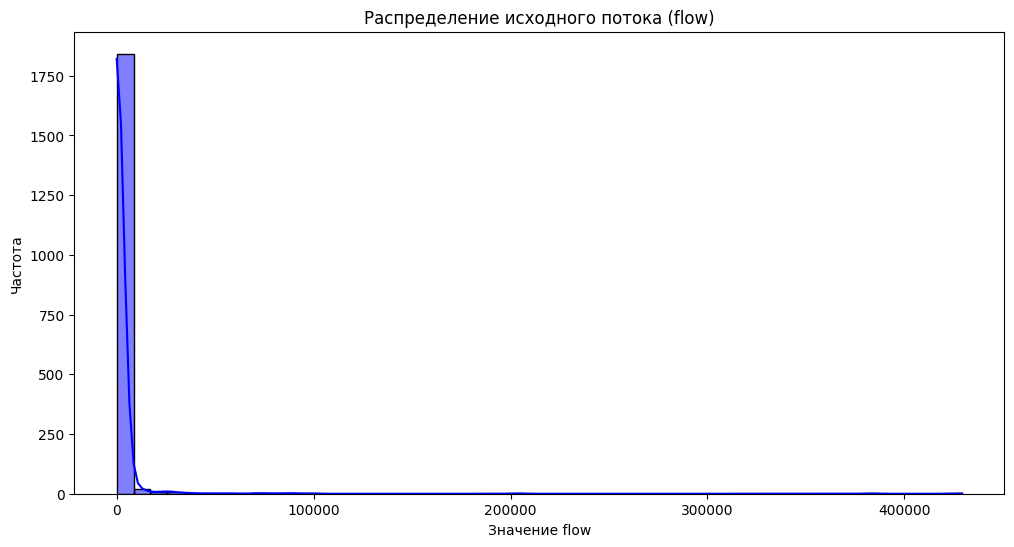

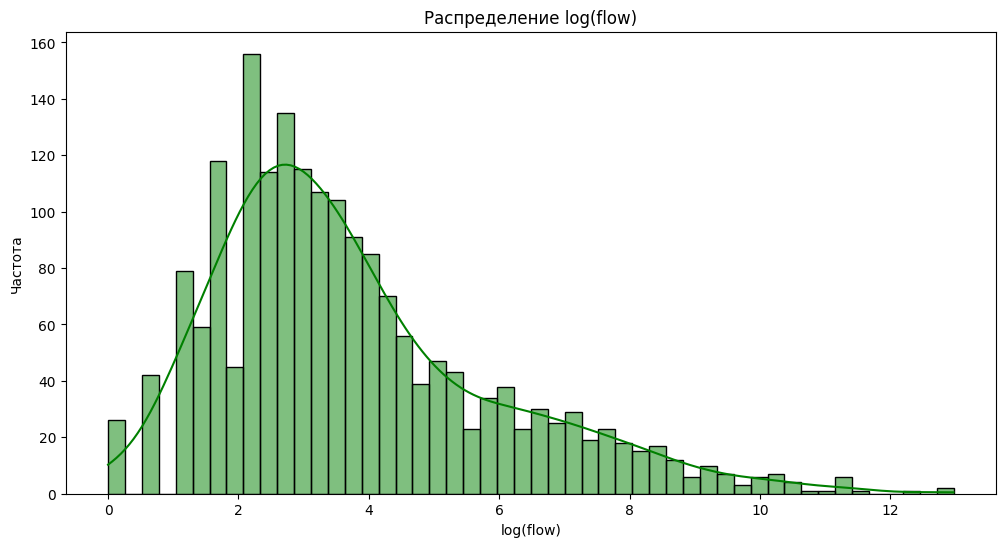

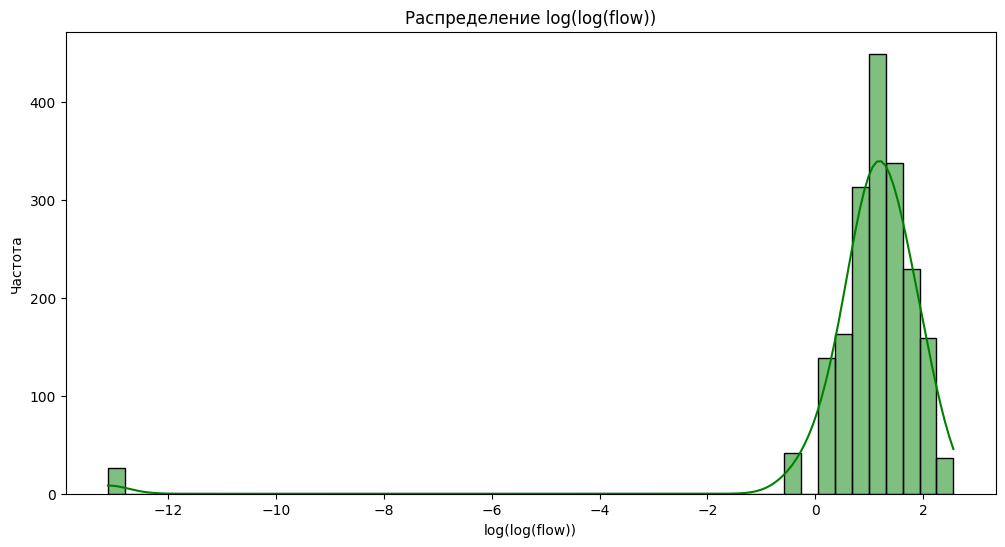

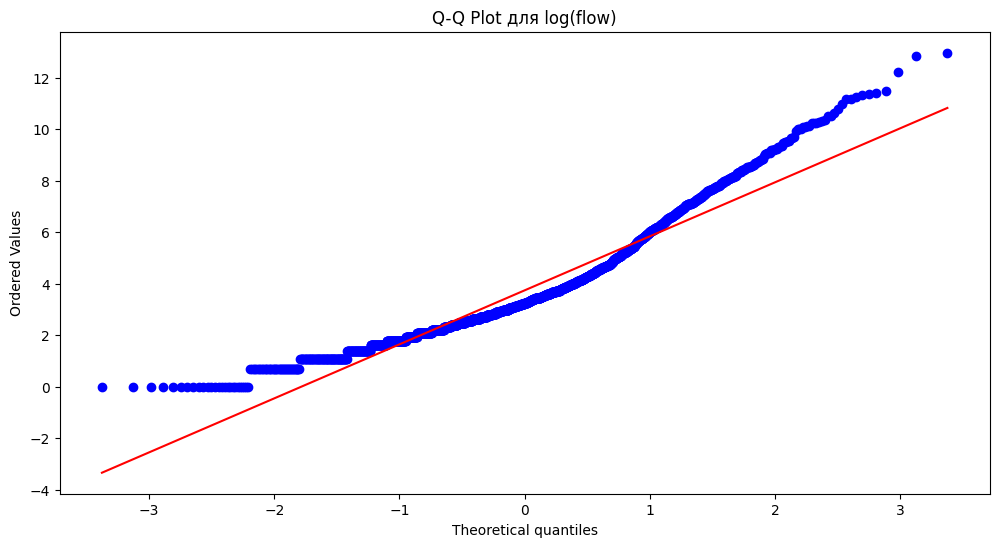

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Гистограмма и KDE
plt.figure(figsize=(12, 6))
sns.histplot(train_data['flow'], kde=True, bins=50, color='blue')
plt.title('Распределение исходного потока (flow)')
plt.xlabel('Значение flow')
plt.ylabel('Частота')
plt.show()

# Добавление константы для избежания log(0)
train_data['log_flow'] = np.log(train_data['flow'] + 1e-6)  # или +1
train_data['log_log_flow'] = np.log(train_data['log_flow'] + 1e-6)  # или +1

# Гистограмма и KDE
plt.figure(figsize=(12, 6))
sns.histplot(train_data['log_flow'], kde=True, bins=50, color='green')
plt.title('Распределение log(flow)')
plt.xlabel('log(flow)')
plt.ylabel('Частота')
plt.show()

# Гистограмма и KDE
plt.figure(figsize=(12, 6))
sns.histplot(train_data['log_log_flow'], kde=True, bins=50, color='green')
plt.title('Распределение log(log(flow))')
plt.xlabel('log(log(flow))')
plt.ylabel('Частота')
plt.show()

from scipy import stats

# Q-Q Plot для log(flow)
plt.figure(figsize=(12, 6))
stats.probplot(train_data['log_flow'], dist="norm", plot=plt)
plt.title('Q-Q Plot для log(flow)')
plt.show()

# # Тест Шапиро-Уилка (для n < 5000)
# shapiro_test = stats.shapiro(train_data['log_flow'].sample(min(5000, len(train_data))))
# print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue}")

# # Тест Колмогорова-Смирнова
# kstest = stats.kstest(train_data['log_flow'], 'norm', 
#                      args=(train_data['log_flow'].mean(), train_data['log_flow'].std()))
# print(f"Kolmogorov-Smirnov p-value: {kstest.pvalue}")

# # Остатки
# residuals = log_pred - train_data['flow']  # train_labels = log(flow)

# # Гистограмма остатков
# plt.figure(figsize=(12, 6))
# sns.histplot(residuals, kde=True, bins=50, color='red')
# plt.title('Распределение остатков модели')
# plt.xlabel('Ошибка (log-шкала)')
# plt.ylabel('Частота')
# plt.show()

# # Q-Q Plot остатков
# stats.probplot(residuals, dist="norm", plot=plt)
# plt.title('Q-Q Plot остатков')
# plt.show()

In [161]:
rf = train_and_save_model(train_data=train_data, label='flow', features=['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d'])

gbr, pt = train_and_save_model_GBR(train_data=train_data, label='flow', features=['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d'])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    1.6s finished


In [163]:
pred_transformed = gbr.predict(np.array(train_data[['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d']]))
pred_flow = pt.inverse_transform(pred_transformed.reshape(-1, 1)).flatten() - 1e-6

# Суммарный поток
print(f"Origin flow:    {train_data.groupby('origin')['flow'].sum().sum()}")
print(f"Predicted flow: {np.sum(pred_flow)}")

Origin flow:    2978046
Predicted flow: 2451489.4526390727


In [164]:
train_data.groupby('origin')['flow'].sum().sum() - np.sum(pred_flow)

526556.5473609273

In [153]:
log_pred = rf.predict(train_data[['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d']])
pred = np.round(np.exp(log_pred + 0.5 * np.var(log_pred - np.log(train_data['flow']))))
pred

d:\programming\github\Migration-model\.venv\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished


array([11., 63., 25., ..., 19., 54., 12.])

In [154]:
train_data = train_data.reset_index(drop=True)
final_df = pd.concat([train_data[['origin', 'destination', 'flow', 'geometry_o', 'geometry_d']], pd.DataFrame(pred, columns=['pred'])], axis=1)
final_df

,origin,destination,flow,geometry_o,geometry_d,pred
0,36001,36005,5,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-73.78352 40.88103, -73.74806 40.871...",11.0
1,36001,36007,29,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-75.85039 42.32773, -75.84379 42.259...",63.0
2,36001,36017,11,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-75.68409 42.73415, -75.42867 42.745...",25.0
3,36001,36019,30,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-74.00667 44.88602, -74.02739 44.995...",29.0
4,36001,36021,728,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-73.75567 42.02348, -73.90778 42.079...",479.0
...,...,...,...,...,...,...
1887,36123,36105,6,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-74.98383 41.50537, -74.98764 41.508...",12.0
1888,36123,36107,57,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-76.25015 42.29668, -76.24914 42.302...",52.0
1889,36123,36109,4,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-76.53835 42.28176, -76.69141 42.284...",19.0
1890,36123,36117,63,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-77.37331 43.12341, -77.37622 43.345...",54.0


Origin flow:    2978046
Predic flow:    2306018.0


<Axes: >

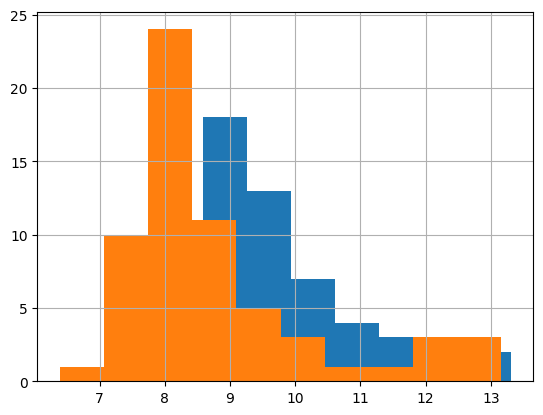

In [155]:
print(f"Origin flow:    {final_df.groupby('origin')['flow'].sum().sum()}")
print(f"Predic flow:    {final_df.groupby('origin')['pred'].sum().sum()}")
np.log(final_df.groupby('origin')['flow'].sum()).hist()
np.log(final_df.groupby('origin')['pred'].sum()).hist()

### Использование SK Mobility

In [57]:
import skmob
from skmob.utils import utils, constants
from skmob.models.gravity import Gravity

import numpy as np
import pandas as pd
import geopandas as gpd

In [73]:
fdf.tessellation['attractiveness'] = (
    fdf.tessellation[['clinic', 'theatre', 'museum', 'park']].sum(axis=1) 
    / fdf.tessellation['population'] 
    * 1000
).round(3)

In [74]:
gravity_singly = Gravity(gravity_type='singly constrained', origin_exp=0.5, destination_exp=2.0, deterrence_func_args=[-4.0])
print(gravity_singly)

Gravity(name="Gravity model", deterrence_func_type="power_law", deterrence_func_args=[-4.0], origin_exp=0.5, destination_exp=2.0, gravity_type="singly constrained")


In [75]:
gravity_singly.fit(fdf, relevance_column='attractiveness')
print(gravity_singly)

Gravity(name="Gravity model", deterrence_func_type="power_law", deterrence_func_args=[-2.813786291575988], origin_exp=1.0, destination_exp=1.8767680918332195, gravity_type="singly constrained")


In [ ]:
np.random.seed(0)

tessellation.loc[tessellation['tile_ID'] == '36061', 'museum'] = 93

synth_fdf = gravity_singly.generate(tessellation,
                                   tile_id_column='tile_ID',
                                   tot_outflows_column='tot_outflow',
                                   relevance_column= 'museum',
                                   out_format='flows')

tessellation.loc[tessellation['tile_ID'] == '36061', 'museum'] = 3

synth_fdf2 = gravity_singly.generate(tessellation,
                                   tile_id_column='tile_ID',
                                   tot_outflows_column='tot_outflow',
                                   relevance_column= 'museum',
                                   out_format='flows')

In [ ]:
inflow = synth_fdf.groupby('destination')['flow'].sum().rename('inflow')
outflow = synth_fdf.groupby('origin')['flow'].sum().rename('outflow')

synth_fdf.tessellation = synth_fdf.tessellation.merge(
    inflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).merge(
    outflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).fillna(0)

synth_fdf.tessellation['inflow'] = synth_fdf.tessellation['inflow'].astype(int)
synth_fdf.tessellation['outflow'] = synth_fdf.tessellation['outflow'].astype(int)



In [ ]:
import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf.tessellation['net_flow'] = synth_fdf.tessellation['inflow'] - synth_fdf.tessellation['outflow']

threshold = synth_fdf['flow'].quantile(0.95)
top_flows = synth_fdf[synth_fdf['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 5% потоков)'
).add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-5% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map 1.html')
m

In [202]:
print(f"Original sum of flow for destination '36061': {fdf[fdf.destination == '36061'].flow.sum()}")
print(f"Modified sum of flow for destination '36061': {synth_fdf[synth_fdf.destination == '36061'].flow.sum():.0f}")


Original sum of flow for destination '36061': 1335838
Modified sum of flow for destination '36061': 1257725


In [ ]:
inflow = synth_fdf2.groupby('destination')['flow'].sum().rename('inflow')
outflow = synth_fdf2.groupby('origin')['flow'].sum().rename('outflow')

synth_fdf2.tessellation = synth_fdf2.tessellation.merge(
    inflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).merge(
    outflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).fillna(0)

synth_fdf2.tessellation['inflow'] = synth_fdf2.tessellation['inflow'].astype(int)
synth_fdf2.tessellation['outflow'] = synth_fdf2.tessellation['outflow'].astype(int)

In [ ]:
import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf2.tessellation['net_flow'] = synth_fdf2.tessellation['inflow'] - synth_fdf2.tessellation['outflow']

threshold = synth_fdf2['flow'].quantile(0.95)
top_flows = synth_fdf2[synth_fdf2['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf2.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 5% потоков)'
).add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-5% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    # Добавляем стрелки с фиксированным размером
    PolyLineTextPath(
        line,
        text="▶",  # Используем треугольник вместо стрелки
        repeat=True,
        offset=5,
        attributes={
            'font-size': '20', 
            'fill': colormap(row['flow']),
            'stroke-width': '0.5'
        }
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map 2.html')
m

In [ ]:
import folium
from folium.features import GeoJson
from folium.plugins import PolyLineTextPath
from shapely.geometry import LineString
import branca.colormap as cm

threshold = synth_fdf2['flow'].quantile(0.95)
top_flows = synth_fdf2[synth_fdf2['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


# 1. Создаем базовую карту
m = synth_fdf2.tessellation.explore(
    column='museum', 
    tiles='CartoDB dark_matter',
    cmap='viridis',
    tooltip=['tile_ID', 'museum', 'inflow', 'outflow'],
    name='Полигоны'
)

# 2. Настраиваем цветовую шкалу
colormap = cm.LinearColormap(
    ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
    vmin=top_flows['flow'].min(),
    vmax=top_flows['flow'].max(),
    caption='Интенсивность миграции'
).add_to(m)

# 3. Добавляем линии со стрелками
lines_layer = folium.FeatureGroup(name='Топ-10% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Получаем координаты для линии (центроиды)
    line_coords = [
        [origin_geom.centroid.y, origin_geom.centroid.x],
        [dest_geom.centroid.y, dest_geom.centroid.x]
    ]
    
    # Создаем линию
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.8
    )
    
    # Добавляем подсказку
    line.add_child(
        folium.Tooltip(f"From {row['origin']} to {row['destination']}<br>Flow: {row['flow']:.1f}")
    )
    
    line.add_to(lines_layer)

# 4. Добавляем элементы управления
folium.LayerControl().add_to(m)
m.add_child(colormap)

# 5. Отображаем карту
m.save('map two.html')
m

C:\Users\Local\AppData\Local\Temp\ipykernel_5108\1380935936.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


In [220]:
synth_fdf3_flow = synth_fdf2.sort_values(['origin', 'destination'])['flow'] - synth_fdf.sort_values(['origin', 'destination'])['flow']

In [221]:
synth_fdf3 = synth_fdf2.sort_values(['origin', 'destination'])[['origin', 'destination']]
synth_fdf3['flow'] = synth_fdf3_flow

In [232]:
synth_fdf2.tessellation['net_flow'] = synth_fdf3['flow']

In [ ]:
import folium
from folium.features import GeoJson
from folium.plugins import PolyLineTextPath
from shapely.geometry import LineString
import branca.colormap as cm

threshold = synth_fdf3['flow'].quantile(0.95)
top_flows = synth_fdf3[synth_fdf3['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


# 1. Создаем базовую карту
m = synth_fdf2.tessellation.explore(
    column='net_flow', 
    tiles='CartoDB dark_matter',
    cmap='viridis',
    tooltip=['tile_ID', 'museum'],
    name='Полигоны'
)

# 2. Настраиваем цветовую шкалу
colormap = cm.LinearColormap(
    ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
    vmin=top_flows['flow'].min(),
    vmax=top_flows['flow'].max(),
    caption='Интенсивность миграции'
).add_to(m)

# 3. Добавляем линии со стрелками
lines_layer = folium.FeatureGroup(name='Топ-10% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Получаем координаты для линии (центроиды)
    line_coords = [
        [origin_geom.centroid.y, origin_geom.centroid.x],
        [dest_geom.centroid.y, dest_geom.centroid.x]
    ]
    
    # Создаем линию
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.8
    )
    
    # Добавляем подсказку
    line.add_child(
        folium.Tooltip(f"From {row['origin']} to {row['destination']}<br>Flow: {row['flow']:.1f}")
    )
    
    line.add_to(lines_layer)

# 4. Добавляем элементы управления
folium.LayerControl().add_to(m)
m.add_child(colormap)

# 5. Отображаем карту
m.save('map diff.html')
m

C:\Users\Local\AppData\Local\Temp\ipykernel_5108\1930447385.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


In [ ]:
import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf2.tessellation['net_flow'] = synth_fdf2.tessellation['inflow'] - synth_fdf2.tessellation['outflow']

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf2.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 5% потоков)'
).add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-5% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    # Добавляем стрелки с фиксированным размером
    PolyLineTextPath(
        line,
        text="▶",  # Используем треугольник вместо стрелки
        repeat=True,
        offset=5,
        attributes={
            'font-size': '20', 
            'fill': colormap(row['flow']),
            'stroke-width': '0.5'
        }
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map 2.html')
m

### Predict ЛО

In [20]:
import pandas as pd
import geopandas as gpd
import numpy as np

import json
from shapely.geometry import shape

import skmob
from skmob.utils import utils, constants
from skmob.models.gravity import Gravity

pd.options.display.max_columns = None

# Укажите путь к вашему файлу
file_path = 'response1.json'

# Загрузите JSON из файла
with open(file_path, 'r', encoding='utf-8') as file:
    json_data = json.load(file)

# Преобразуйте строку в словарь (если JSON внутри строки)
feature_collection1 = json.loads(json_data[0])
feature_collection2 = json.loads(json_data[1])
feature_collection3 = json.loads(json_data[2])

gdf1 = gpd.GeoDataFrame.from_features(feature_collection1['features'], crs='EPSG:4326')
gdf2 = gpd.GeoDataFrame.from_features(feature_collection1['features'], crs='EPSG:4326')
gdf3 = gpd.GeoDataFrame.from_features(feature_collection3['features'], crs='EPSG:4326')

gdf1['Исходящая'] = gdf1['Исходящая. Моложе трудоспособного возраста'] + \
                    gdf1['Исходящая. Трудоспособного возраста'] + \
                    gdf1['Исходящая. Старше трудоспособного возраста']

gdf1['Входящая'] = gdf1['Входящая. Моложе трудоспособного возраста'] + \
                    gdf1['Входящая. Трудоспособного возраста'] + \
                    gdf1['Входящая. Старше трудоспособного возраста']

In [62]:
gdf1 = gdf1[['geometry', 'territory_id', 'tile_ID', 'centre_point',
       'Входящая',
       'Исходящая',
       'Численность населения (чел.)',]]
gdf1

,geometry,territory_id,tile_ID,centre_point,Входящая,Исходящая,Численность населения (чел.)
0,"POLYGON ((34.42169 59.68391, 34.42428 59.6715,...",3,Самойловское сельское поселение,POINT (34.28177984715711 59.43240373518366),188.0,155.0,2096.0
1,"POLYGON ((34.30682 59.71494, 34.30791 59.71295...",4,Большедворское сельское поселение,POINT (33.95668611725517 59.66791931803934),134.0,102.0,1486.0
2,"POLYGON ((34.14251 59.48759, 34.13616 59.49064...",5,Пикалевское городское поселение,POINT (34.14548262805941 59.52005414868216),582.0,591.0,19250.0
3,"POLYGON ((34.05997 59.15087, 34.06007 59.14658...",6,Борское сельское поселение,POINT (33.858458844651615 59.34944196343539),253.0,249.0,3272.0
4,"POLYGON ((34.06836 59.40315, 34.05535 59.40393...",7,Бокситогорское городское поселение,POINT (33.954601686386006 59.48063828225926),612.0,694.0,14606.0
...,...,...,...,...,...,...,...
183,"POLYGON ((30.52049 59.69087, 30.52316 59.69108...",202,Фёдоровское городское поселение,POINT (30.54880204887443 59.639497680374156),267.0,276.0,4562.0
184,"POLYGON ((31.01271 59.63362, 31.01394 59.63327...",203,Нурминское сельское поселение,POINT (31.04731042982716 59.574849273243245),44.0,44.0,2977.0
185,"POLYGON ((30.58336 59.64993, 30.58367 59.65002...",204,Красноборское городское поселение,POINT (30.687803815369318 59.6771336096464),154.0,226.0,4657.0
186,"POLYGON ((31.13126 59.08942, 31.13522 59.09693...",205,Трубникоборское сельское поселение,POINT (31.38540255243136 59.22762950766781),36.0,51.0,1479.0


In [ ]:
import osmnx as ox
import geopandas as gpd
from tqdm import tqdm

# Определение тегов OSM
tags_config = {
    'clinic': {'amenity': 'clinic'},
    'theatre': {'amenity': 'theatre'},
    'museum': {'tourism': 'museum'},
    'park': {'leisure': 'park'}
}

# Функция для подсчета объектов
def count_pois(polygon, tag):
    try:
        print(f'"{list(tag.keys())[0]}":"{list(tag.values())[0]}"')
        gdf = ox.features_from_polygon(
            polygon,
            tags=tag,
            # custom_filter=f'"{list(tag.keys())[0]}":"{list(tag.values())[0]}"'
        )
        return gdf[gdf.geometry.notnull()].shape[0]
    except:
        return 0

# Добавляем колонки для каждого типа объектов
for category in tags_config:
    gdf1[f'{category}'] = 0

# Обрабатываем все полигоны с визуализацией прогресса
for idx, row in tqdm(gdf1.iterrows(), total=len(gdf1)):
    geom = row.geometry
    for category, tag in tags_config.items():
        count = count_pois(geom, tag)
        gdf1.at[idx, f'{category}'] = count

# Результат
# print(gdf1[['tile_ID', 'clinic_count', 'theatre_count', 'museum_count', 'park_count']].head())

In [ ]:
gdf1['attractiveness'] = (
    gdf1[['clinic', 'theatre', 'museum', 'park']].sum(axis=1) 
    / gdf1['Численность населения (чел.)'] 
    * 1000
).round(3)


In [106]:
gdf1.loc[gdf1['tile_ID'].isin(['Муринское городское поселение', 'Новодевяткинское сельское поселение'])]

,geometry,territory_id,tile_ID,centre_point,Входящая,Исходящая,Численность населения (чел.),clinic,theatre,museum,park,attractiveness
33,"MULTIPOLYGON (((30.41847 60.04941, 30.41849 60...",39,Муринское городское поселение,POINT (30.460460407800305 60.05191828171302),20224.0,7141.0,90571.0,11,1,0,8,0.221
44,"MULTIPOLYGON (((30.46433 60.08246, 30.46468 60...",50,Новодевяткинское сельское поселение,POINT (30.477487013924357 60.06540340854897),1836.0,1147.0,22699.0,3,0,0,0,0.132


In [122]:
synth_fdf.loc[synth_fdf['origin'].isin(['Новодевяткинское сельское поселение'])].sum().values[2]

1808

In [137]:
synth_fdf = gravity_singly.generate(gdf1,
                                   tile_id_column='tile_ID',
                                   tot_outflows_column='Входящая',
                                   relevance_column= 'attractiveness',
                                   out_format='flows')

synth_fdf['flow'] = synth_fdf['flow'].astype(int)

  0%|          | 0/188 [00:00<?, ?it/s]

100%|██████████| 188/188 [00:00<00:00, 2927.40it/s]
d:\programming\github\Migration-model\.venv\lib\site-packages\skmob\models\gravity.py:43: RuntimeWarning: divide by zero encountered in power
  return np.power(x, exponent)
d:\programming\github\Migration-model\.venv\lib\site-packages\skmob\models\gravity.py:298: RuntimeWarning: invalid value encountered in multiply
  trip_probs_matrix = trip_probs_matrix * relevances_dest ** self.destination_exp * \
d:\programming\github\Migration-model\.venv\lib\site-packages\skmob\models\gravity.py:378: RuntimeWarning: invalid value encountered in divide
  trip_probs_matrix = (trip_probs_matrix.T / np.sum(trip_probs_matrix, axis=1)).T


In [138]:
synth_fdf.tessellation = gdf1

In [139]:
inflow = synth_fdf.groupby('destination')['flow'].sum().rename('inflow')
outflow = synth_fdf.groupby('origin')['flow'].sum().rename('outflow')

synth_fdf.tessellation = synth_fdf.tessellation.merge(
    inflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).merge(
    outflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).fillna(0)

In [140]:
synth_fdf.tessellation['inflow'] = synth_fdf.tessellation['inflow'].astype(int)
synth_fdf.tessellation['outflow'] = synth_fdf.tessellation['outflow'].astype(int)


import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf.tessellation['net_flow'] = synth_fdf.tessellation['inflow'] - synth_fdf.tessellation['outflow']

threshold = synth_fdf['flow'].quantile(0.99)
top_flows = synth_fdf[synth_fdf['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((synth_fdf['flow'] - synth_fdf['flow'].min()) / (synth_fdf['flow'].max() - synth_fdf['flow'].min()))

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 'attractiveness', 'Численность населения (чел.)'
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 1% потоков)'
) # .add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-1% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
# m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map ЛО.html')
m

C:\Users\Local\AppData\Local\Temp\ipykernel_952\2715300122.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_flows['line_weight'] = 1 + 8 * ((synth_fdf['flow'] - synth_fdf['flow'].min()) / (synth_fdf['flow'].max() - synth_fdf['flow'].min()))


In [ ]:
# Исходящая как генерация
synth_fdf.loc[synth_fdf['origin'].isin(['Новодевяткинское сельское поселение'])].sum().values[2], \
synth_fdf.loc[synth_fdf['destination'].isin(['Новодевяткинское сельское поселение'])].sum().values[2], \
synth_fdf.loc[synth_fdf['origin'].isin(['Муринское городское поселение'])].sum().values[2], \
synth_fdf.loc[synth_fdf['destination'].isin(['Муринское городское поселение'])].sum().values[2]

(1125, 5278, 7085, 1526)

In [141]:
# Входящая как генерация
synth_fdf.loc[synth_fdf['origin'].isin(['Новодевяткинское сельское поселение'])].sum().values[2], \
synth_fdf.loc[synth_fdf['destination'].isin(['Новодевяткинское сельское поселение'])].sum().values[2], \
synth_fdf.loc[synth_fdf['origin'].isin(['Муринское городское поселение'])].sum().values[2], \
synth_fdf.loc[synth_fdf['destination'].isin(['Муринское городское поселение'])].sum().values[2]

(1808, 14616, 20162, 2427)

In [136]:
gdf1.loc[gdf1['tile_ID'].isin(['Новодевяткинское сельское поселение'])]['Входящая'].sum(), \
gdf1.loc[gdf1['tile_ID'].isin(['Новодевяткинское сельское поселение'])]['Исходящая'].sum(), \
gdf1.loc[gdf1['tile_ID'].isin(['Муринское городское поселение'])]['Входящая'].sum(), \
gdf1.loc[gdf1['tile_ID'].isin(['Муринское городское поселение'])]['Исходящая'].sum()

(1836.0, 1147.0, 20224.0, 7141.0)